In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

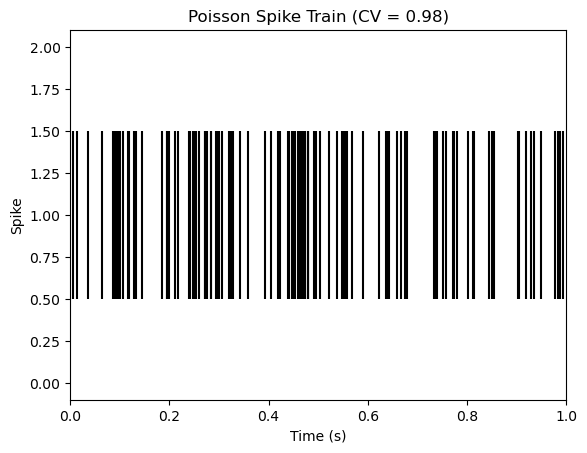

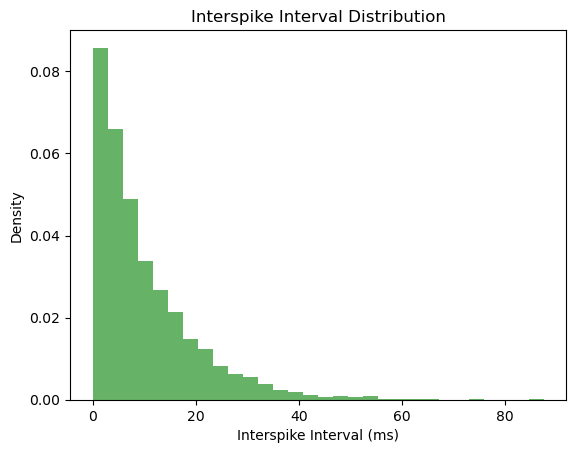

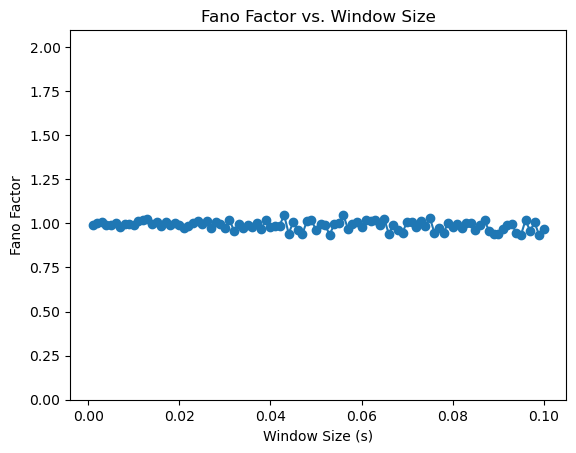

Coefficient of Variation (CV): 0.98
Fano Factor: 1.05


In [2]:
fire_rate = 100 # Hz # Constant firing rate
dur = 50 #seconds
window_size = np.arange(1, 101, 1) / 1000# seconds

def poisson_spike_generator(rate, duration, window_size):
    expected_spikes = rate * duration 
    spike_times = np.cumsum(np.random.exponential(1/rate, size=int(expected_spikes)))#np.sort(np.random.uniform(0, duration, size=int(expected_spikes)))
    interspike_intervals = np.diff(spike_times)

    mean_isi = np.mean(interspike_intervals)
    std_isi = np.std(interspike_intervals)
    coefficient_of_variation = std_isi / mean_isi if mean_isi > 0 else 0



    fano_factor = []
    for w in window_size:
        bins = np.arange(0, duration + w, w)
        spike_counts, _ = np.histogram(spike_times, bins=bins)

        fano = np.var(spike_counts)/ np.mean(spike_counts) if np.mean(spike_counts) > 0 else 0
        fano_factor.append(fano)


    return spike_times, interspike_intervals, coefficient_of_variation, fano_factor

spike_times, interspike_intervals, cv, fano = poisson_spike_generator(fire_rate, dur, window_size)

plt.eventplot(spike_times, lineoffsets=1, colors='black')
plt.xlim(0,1)
plt.title(f'Poisson Spike Train (CV = {cv:.2f})')
plt.xlabel('Time (s)')
plt.ylabel('Spike')
plt.show()

plt.hist(interspike_intervals * 1000, bins=30, density=True, alpha=0.6, color='g')
plt.title('Interspike Interval Distribution')
plt.xlabel('Interspike Interval (ms)')
plt.ylabel('Density')
plt.show()

plt.plot(window_size, fano, marker='o')
plt.title('Fano Factor vs. Window Size')
plt.ylim(0, max(fano) * 2)
plt.xlabel('Window Size (s)')
plt.ylabel('Fano Factor')
plt.show()

print(f'Coefficient of Variation (CV): {cv:.2f}')
print(f'Fano Factor: {max(fano):.2f}')


Refractory period added

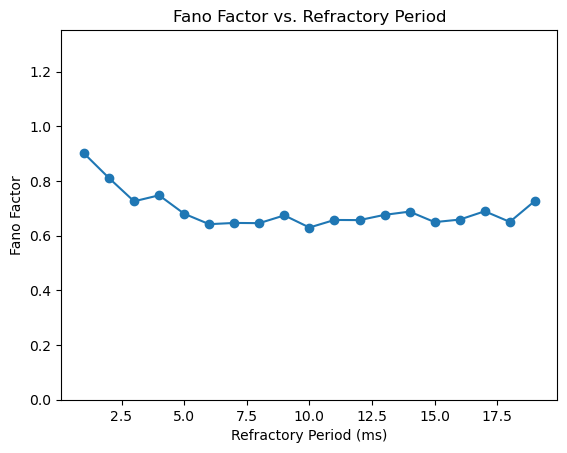

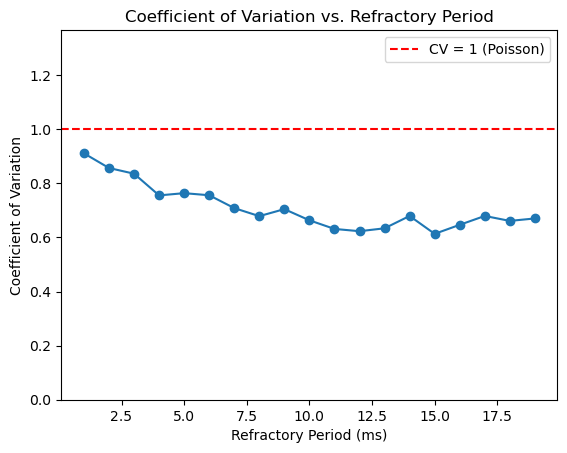

In [3]:
def refractory_possion(r0, tau_ref, duration, dt=1e-4):
    spike_times = []
    t=0
    last_spike_time = -np.inf

    times = []
    rates = []
    while t < duration:
        if last_spike_time == -np.inf:
            rate = r0
        else:
            rate += dt * (r0 - rate)/tau_ref #r0 * (1 - np.exp(-(t - last_spike_time) / tau_ref))
        
        if np.random.rand() < rate * dt:
            spike_times.append(t)
            last_spike_time = t
            rate = 0 # Reset rate immediately after a spike

        times.append(t)
        rates.append(rate)
        t += dt

    interspike_intervals = np.diff(spike_times)
    mean_isi = np.mean(interspike_intervals)
    std_isi = np.std(interspike_intervals)
    coefficient_of_variation = std_isi / mean_isi if mean_isi > 0 else 0

    return np.array(spike_times), np.array(times), np.array(rates), coefficient_of_variation


tau_ref_range = np.arange(1e-3, 20e-3, 0.001) # Refractory periods from 1 ms to 20 ms
r0 = 100 # Firing rate in Hz
duration = 10.0 # Duration of simulation in seconds
dt = 1e-4 # Time step


cv_values = []
for tau_ref in tau_ref_range:
    spike_times, times, rates, cv = refractory_possion(r0, tau_ref, duration, dt)
    cv_values.append(cv)

def fano_factor_refractory(spike_times, duration, window_size):
    bins = np.arange(0, duration + window_size, window_size)
    spike_counts, _ = np.histogram(spike_times, bins=bins)

    fano = np.var(spike_counts) / np.mean(spike_counts) if np.mean(spike_counts) > 0 else 0
    return fano

fano_values = []
for tau_ref in tau_ref_range:
    spike_times, times, rates, cv = refractory_possion(r0, tau_ref, duration, dt)
    fano = fano_factor_refractory(spike_times, duration, 0.01) # Using a fixed window size of 10 ms
    fano_values.append(fano)

plt.plot(tau_ref_range * 1000, fano_values, marker='o')
plt.title('Fano Factor vs. Refractory Period')
plt.xlabel('Refractory Period (ms)')
plt.ylabel('Fano Factor')
plt.ylim(0, max(fano_values) * 1.5)
plt.show()

plt.plot(tau_ref_range * 1000, cv_values, marker='o')
plt.title('Coefficient of Variation vs. Refractory Period')

plt.xlabel('Refractory Period (ms)')
plt.ylabel('Coefficient of Variation')
plt.axhline(1, color='red', linestyle='--', label='CV = 1 (Poisson)')

plt.ylim(0, max(cv_values) * 1.5)
plt.legend()
plt.show()
        

